Імпорти

In [28]:
import csv
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=6)


Функціональний розв'язок і звітний вивід

In [29]:
def read_numeric_csv(file_path, sample_size):
    for delimiter in (",", ";"):
        try:
            with open(file_path, newline="", encoding="utf-8") as file:
                reader = csv.reader(file, delimiter=delimiter)
                header = next(reader)
                rows = []
                for row in reader:
                    if not row:
                        continue
                    rows.append([float(value) for value in row[1:]])
                    if len(rows) == sample_size:
                        break
            if rows:
                return header[1:], np.array(rows, dtype=float)
        except ValueError:
            continue
    raise ValueError("Не вдалося прочитати файл з числовими даними")


def load_and_normalize(file_path, n1, n2, n3, m, sample_size):
    column_names, matrix = read_numeric_csv(file_path, sample_size)
    n_total_x = n1 + n2 + n3

    x_matrix = matrix[:, :n_total_x]
    y_matrix = matrix[:, n_total_x:n_total_x + m]

    x_min = x_matrix.min(axis=0)
    x_max = x_matrix.max(axis=0)
    x_diff = np.where(x_max - x_min == 0, 1, x_max - x_min)
    x_norm = (x_matrix - x_min) / x_diff

    # Для Y використовуємо спільний діапазон, щоб зберегти відмінності між виходами.
    y_min = float(y_matrix.min())
    y_max = float(y_matrix.max())
    y_diff = y_max - y_min if y_max != y_min else 1.0
    y_norm = (y_matrix - y_min) / y_diff

    return {
        "column_names": column_names,
        "x1_names": column_names[:n1],
        "x2_names": column_names[n1:n1 + n2],
        "x3_names": column_names[n1 + n2:n_total_x],
        "y_names": column_names[n_total_x:n_total_x + m],
        "x1": x_norm[:, :n1],
        "x2": x_norm[:, n1:n1 + n2],
        "x3": x_norm[:, n1 + n2:n_total_x],
        "y": y_norm,
        "y_min": y_min,
        "y_max": y_max,
    }


def chebyshev(x, k):
    if k == 0:
        return np.ones_like(x)
    if k == 1:
        return 2 * x - 1

    z = 2 * x - 1
    t_prev2 = np.ones_like(x)
    t_prev1 = z
    for _ in range(2, k + 1):
        t_prev2, t_prev1 = t_prev1, 2 * z * t_prev1 - t_prev2
    return t_prev1


def solve_lstsq(a, b):
    return np.linalg.lstsq(a, b, rcond=None)[0]


def calc_b_values(y):
    return ((y.max(axis=1) + y.min(axis=1)) / 2.0).reshape(-1, 1)


def build_tz_matrix(x_groups, degrees):
    columns = []
    for x_matrix, degree in zip(x_groups, degrees):
        for j in range(x_matrix.shape[1]):
            for k in range(degree + 1):
                columns.append(chebyshev(x_matrix[:, j], k))
    return np.column_stack(columns)


def split_lambda_coefficients(lambdas, dims, degrees):
    matrices = []
    start = 0
    for dim, degree in zip(dims, degrees):
        width = dim * (degree + 1)
        matrices.append(lambdas[start:start + width].reshape(dim, degree + 1))
        start += width
    return matrices


def calculate_psi(lambda_matrix, x, degree):
    psi = np.zeros((x.shape[0], x.shape[1]))
    for j in range(x.shape[1]):
        for k in range(degree + 1):
            psi[:, j] += lambda_matrix[j, k] * chebyshev(x[:, j], k)
    return psi


def incoherence(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))


def denormalize(matrix, mins, maxs):
    return matrix * (maxs - mins) + mins


def build_comparison_table(y_names, y_real, y_pred):
    header = ["q"]
    for name in y_names:
        header.extend([f"{name}_real", f"{name}_pred"])

    rows = []
    for idx in range(y_real.shape[0]):
        row = [str(idx + 1)]
        for column in range(y_real.shape[1]):
            row.extend([
                f"{y_real[idx, column]:.6f}",
                f"{y_pred[idx, column]:.6f}",
            ])
        rows.append(row)
    return header, rows


def print_matrix(title, matrix, row_labels=None, col_labels=None, decimals=6):
    print(f"\n{title}")
    matrix = np.atleast_2d(matrix)

    if row_labels is None:
        row_labels = [str(i + 1) for i in range(matrix.shape[0])]
    if col_labels is None:
        col_labels = [f"c{i + 1}" for i in range(matrix.shape[1])]

    formatted = [[f"{value:.{decimals}f}" for value in row] for row in matrix]
    widths = []
    for idx, label in enumerate(col_labels):
        widths.append(max(len(label), max(len(row[idx]) for row in formatted)))
    row_label_width = max(len("row"), max(len(label) for label in row_labels))

    header = " " * (row_label_width + 3) + "  ".join(
        label.rjust(widths[idx]) for idx, label in enumerate(col_labels)
    )
    print(header)
    for label, row in zip(row_labels, formatted):
        values = "  ".join(value.rjust(widths[idx]) for idx, value in enumerate(row))
        print(f"{label.rjust(row_label_width)} | {values}")


def print_table(title, header, rows):
    print(f"\n{title}")
    widths = [len(name) for name in header]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(value))

    line = " | ".join(header[idx].rjust(widths[idx]) for idx in range(len(header)))
    print(line)
    print("-+-".join("-" * width for width in widths))
    for row in rows:
        print(" | ".join(row[idx].rjust(widths[idx]) for idx in range(len(row))))


def wrap_expression(prefix, terms, indent="    ", terms_per_line=4):
    lines = []
    current = prefix
    for idx, term in enumerate(terms):
        separator = "" if idx == 0 else " + "
        candidate = current + separator + term
        if idx > 0 and (idx % terms_per_line == 0):
            lines.append(current)
            current = indent + term
        else:
            current = candidate
    lines.append(current)
    return "\n".join(lines)


def build_component_formula(output_index, group_index, var_names, lambda_matrix, a_vector):
    terms = []
    for row_idx, var_name in enumerate(var_names):
        for degree in range(lambda_matrix.shape[1]):
            coefficient = a_vector[row_idx] * lambda_matrix[row_idx, degree]
            terms.append(f"{coefficient:.8f} T*({var_name}^{degree})")
    return wrap_expression(f"Ф{output_index + 1}{group_index}(x) = ", terms)


def build_final_formula(output_index, c_matrix):
    terms = [
        f"{c_matrix[group_idx, output_index]:.15f}*Ф{output_index + 1}{group_idx + 1}"
        for group_idx in range(c_matrix.shape[0])
    ]
    return wrap_expression(f"Ф{output_index + 1}(x) = ", terms, indent="         ", terms_per_line=3)


def fit_model(x1, x2, x3, y, p1, p2, p3):
    tz_matrix = build_tz_matrix((x1, x2, x3), (p1, p2, p3))
    b_vector = calc_b_values(y)
    lambda_all = solve_lstsq(tz_matrix, b_vector)
    lambda_x1, lambda_x2, lambda_x3 = split_lambda_coefficients(
        lambda_all,
        (x1.shape[1], x2.shape[1], x3.shape[1]),
        (p1, p2, p3),
    )

    psi_1 = calculate_psi(lambda_x1, x1, p1)
    psi_2 = calculate_psi(lambda_x2, x2, p2)
    psi_3 = calculate_psi(lambda_x3, x3, p3)

    a1 = solve_lstsq(psi_1, y)
    a2 = solve_lstsq(psi_2, y)
    a3 = solve_lstsq(psi_3, y)

    phi_1 = psi_1 @ a1
    phi_2 = psi_2 @ a2
    phi_3 = psi_3 @ a3

    c_matrix = np.zeros((3, y.shape[1]))
    y_pred = np.zeros_like(y)
    for idx in range(y.shape[1]):
        current = np.column_stack((phi_1[:, idx], phi_2[:, idx], phi_3[:, idx]))
        c_matrix[:, idx] = solve_lstsq(current, y[:, idx]).ravel()
        y_pred[:, idx] = current @ c_matrix[:, idx]

    return {
        "tz_matrix": tz_matrix,
        "b_vector": b_vector,
        "lambda_x1": lambda_x1,
        "lambda_x2": lambda_x2,
        "lambda_x3": lambda_x3,
        "a1": a1,
        "a2": a2,
        "a3": a3,
        "phi_1": phi_1,
        "phi_2": phi_2,
        "phi_3": phi_3,
        "c_matrix": c_matrix,
        "y_pred": y_pred,
        "rmse": incoherence(y_pred, y),
    }


def print_results(data, results):
    print("ВІДНОВЛЕННЯ ФУНКЦІОНАЛЬНИХ ЗАЛЕЖНОСТЕЙ")
    print("Метод вибору b_iq0: один спільний вектор b для всіх функцій Y_i")
    print("Метод розв'язання: метод найменших квадратів (МНК)")
    print("Нормалізація X: поколоночна, нормалізація Y: спільний діапазон для всіх виходів")
    print("Коефіцієнти λ є спільними для всіх Y_i, окремими є лише A та c")

    print("\n1. Формуємо вектор b на нормалізованих даних")
    b_rows = [f"q{idx + 1}" for idx in range(results["b_vector"].shape[0])]
    print_matrix("Вектор b", results["b_vector"], row_labels=b_rows, col_labels=["b"], decimals=6)

    print("\n2. Знаходимо спільні коефіцієнти λ для кожної групи змінних")
    lambda_cols = [f"T{k}" for k in range(results["lambda_x1"].shape[1])]
    print_matrix("Lambda для X1", results["lambda_x1"], row_labels=data["x1_names"], col_labels=lambda_cols)
    print_matrix("Lambda для X2", results["lambda_x2"], row_labels=data["x2_names"], col_labels=lambda_cols)
    print_matrix("Lambda для X3", results["lambda_x3"], row_labels=data["x3_names"], col_labels=lambda_cols)

    print("\n3. Знаходимо матриці A1, A2, A3")
    print_matrix("Матриця A1", results["a1"].T, row_labels=data["y_names"], col_labels=data["x1_names"])
    print_matrix("Матриця A2", results["a2"].T, row_labels=data["y_names"], col_labels=data["x2_names"])
    print_matrix("Матриця A3", results["a3"].T, row_labels=data["y_names"], col_labels=data["x3_names"])

    print("\n4. Виразимо частинні функції Фik(x) через поліноми Чебишева")
    for output_index, y_name in enumerate(data["y_names"]):
        print(f"\nДля {y_name}:")
        print(build_component_formula(output_index, 1, data["x1_names"], results["lambda_x1"], results["a1"][:, output_index]))
        print(build_component_formula(output_index, 2, data["x2_names"], results["lambda_x2"], results["a2"][:, output_index]))
        print(build_component_formula(output_index, 3, data["x3_names"], results["lambda_x3"], results["a3"][:, output_index]))

    print("\n5. Тепер виразимо всі функції Фi(x) через Фi1, Фi2, Фi3")
    for output_index in range(len(data["y_names"])):
        print(build_final_formula(output_index, results["c_matrix"]))

    print_matrix("Матриця C", results["c_matrix"].T, row_labels=data["y_names"], col_labels=["c1", "c2", "c3"])

    print("\n6. Порівняємо реальні та відновлені значення")
    y_real = denormalize(data["y"], data["y_min"], data["y_max"])
    y_pred = denormalize(results["y_pred"], data["y_min"], data["y_max"])
    header, rows = build_comparison_table(data["y_names"], y_real, y_pred)
    print_table("Порівняння реальних і відновлених значень Y", header, rows)

    residual_rows = []
    for idx, name in enumerate(data["y_names"]):
        residual_rows.append([
            name,
            f"{results['rmse'][idx]:.6f}",
            f"{np.sqrt(np.mean((y_pred[:, idx] - y_real[:, idx]) ** 2)):.6f}",
        ])
    print_table("Нев'язка", ["Y", "RMSE_norm", "RMSE_real"], residual_rows)


def plot_results(y_true, y_pred, y_names):
    fig, axes = plt.subplots(y_true.shape[1], 1, figsize=(9, 4 * y_true.shape[1]), sharex=True)
    if y_true.shape[1] == 1:
        axes = [axes]

    rmse_norm = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    y_min_common = min(float(y_true.min()), float(y_pred.min()))
    y_max_common = max(float(y_true.max()), float(y_pred.max()))
    padding = 0.03 * (y_max_common - y_min_common if y_max_common != y_min_common else 1.0)

    x_axis = range(1, y_true.shape[0] + 1)
    for idx, ax in enumerate(axes):
        ax.plot(x_axis, y_true[:, idx], color="darkblue", linewidth=2, marker="o", markersize=3, label=f"{y_names[idx]} (норм.)")
        ax.plot(x_axis, y_pred[:, idx], color="tab:red", linewidth=1.8, linestyle="--", label=f"Ф{idx + 1} (норм.)")
        ax.set_title(f"Ф: {y_names[idx]}. Нев'язка: {rmse_norm[idx]:.6f}")
        ax.set_ylim(y_min_common - padding, y_max_common + padding)
        ax.set_ylabel("norm")
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("q")
    plt.tight_layout()
    plt.show()


# ПАРАМЕТРИ ТА ЗАПУСК

ВІДНОВЛЕННЯ ФУНКЦІОНАЛЬНИХ ЗАЛЕЖНОСТЕЙ
Метод вибору b_iq0: один спільний вектор b для всіх функцій Y_i
Метод розв'язання: метод найменших квадратів (МНК)
Нормалізація X: поколоночна, нормалізація Y: спільний діапазон для всіх виходів
Коефіцієнти λ є спільними для всіх Y_i, окремими є лише A та c

1. Формуємо вектор b на нормалізованих даних

Вектор b
             b
 q1 | 0.218593
 q2 | 0.223367
 q3 | 0.223985
 q4 | 0.226190
 q5 | 0.229978
 q6 | 0.235349
 q7 | 0.217846
 q8 | 0.219397
 q9 | 0.222532
q10 | 0.227253
q11 | 0.219758
q12 | 0.753829
q13 | 0.618100
q14 | 0.191943
q15 | 0.194878
q16 | 0.199397
q17 | 0.205501
q18 | 0.213188
q19 | 0.280184
q20 | 0.291460
q21 | 0.184536
q22 | 0.221202
q23 | 0.289736
q24 | 0.359854
q25 | 0.344526
q26 | 0.275246
q27 | 0.198979
q28 | 0.193015
q29 | 0.188635
q30 | 0.185840
q31 | 0.184629
q32 | 0.255445
q33 | 0.253116
q34 | 0.307487
q35 | 0.332365
q36 | 0.348719
q37 | 0.319274
q38 | 0.318575
q39 | 0.340566
q40 | 0.352259

2. Знаходимо спільні коефіцієнт

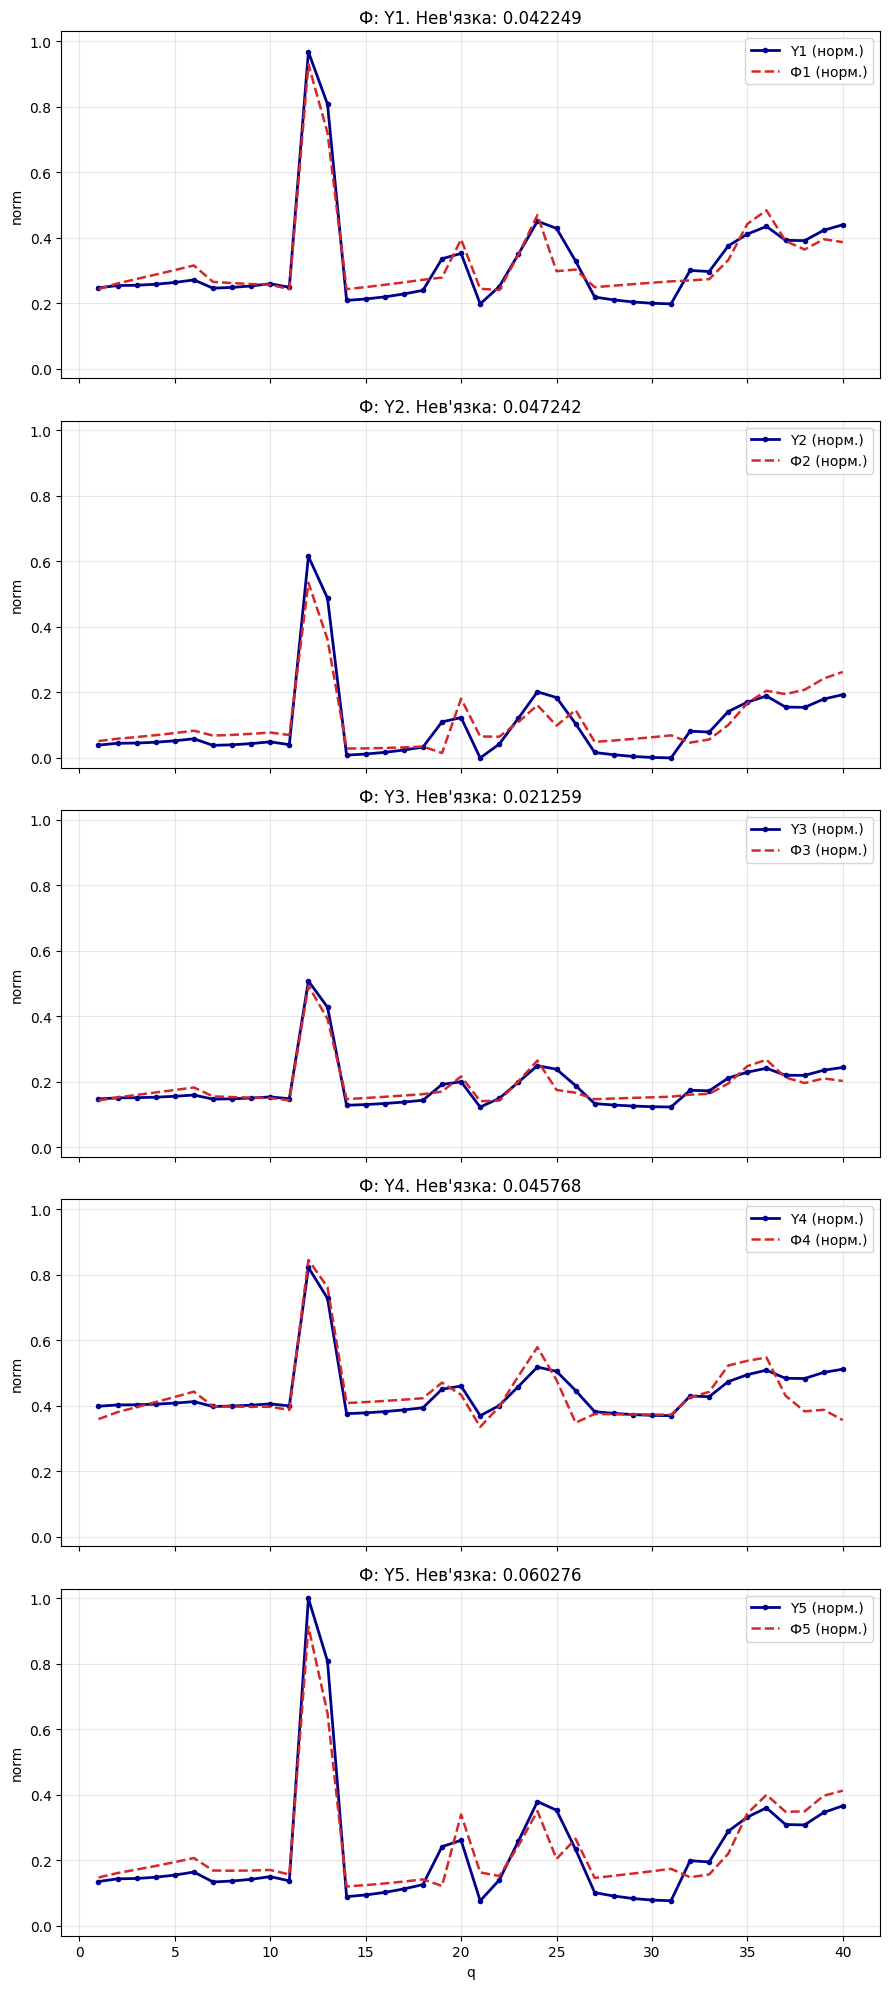

In [30]:
N1, N2, N3, M = 2, 2, 2, 5
P1, P2, P3 = 3, 3, 3
SIZE = 40

data = load_and_normalize("data.csv", n1=N1, n2=N2, n3=N3, m=M, sample_size=SIZE)
results = fit_model(data["x1"], data["x2"], data["x3"], data["y"], p1=P1, p2=P2, p3=P3)

print_results(data, results)
plot_results(data["y"], results["y_pred"], data["y_names"])
